# 前向欧拉法求解自由落体运动

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学 
- 2026年9月13日

2026年9月13日

自由落体是仅受重力作用的运动，取竖直向下为正方向，其运动由如下一阶微分方程组描述：

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = g
$$

其中 $g \approx 9.8\ \mathrm{m/s^2}$。解析解为

$$
v(t) = v_0 + g\,t, \qquad x(t) = x_0 + v_0\,t + \tfrac{1}{2}g\,t^2
$$

**总机械能** $E = \tfrac{1}{2}mv^2 - mgx$（取 $x=0$ 处势能为零，因 $x$ 轴向下故势能带负号）在解析解中严格守恒：动能的增加恰好来自重力势能的减少。我们将用它检验数值方法的能量行为。

**前向欧拉法（Forward Euler）** 的离散格式：

$$
v_{n+1} = v_n + h\,g, \qquad x_{n+1} = x_n + h\,v_n
$$

**运行之前，先把你的预测写下来**：

1. 速度更新 $v_{n+1} = v_n + h\,g$ 算出的速度与解析解是什么关系？
2. 位置更新 $x_{n+1} = x_n + h\,v_n$ 用的是**旧速度**——数值位置会超前还是滞后于解析解？误差随 $t$ 如何变化？
3. 总机械能在数值解中还守恒吗？试着把更新格式代入 $E_{n+1} = \tfrac{1}{2}m\,v_{n+1}^2 - mg\,x_{n+1}$，算出每步能量变化 $\Delta E$——它与当前状态有关吗？由此判断 $E_n$ 随 $n$ 增长的"形状"（线性？指数？）。
4. 若把步长 $h$ 减半，位置误差与能量漂移各变为几分之一？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_free_fall(x0, v0, g, h, n_steps):
    """前向欧拉法求解自由落体 dx/dt = v, dv/dt = g
    返回时间、位置、速度数组（长度 n_steps + 1）"""
    t = np.arange(n_steps + 1) * h
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        x[n + 1] = x[n] + h * v[n]
        v[n + 1] = v[n] + h * g
    return t, x, v

位置最大相对误差 = 1.000e+00
速度最大相对误差 = 2.072e-16
解析总能量 = 0.000e+00 J（守恒）
数值总能量漂移 = 1.200e+02 J
末速度 = 49.00 m/s，末位置 = 110.25 m（解析值 122.50 m）


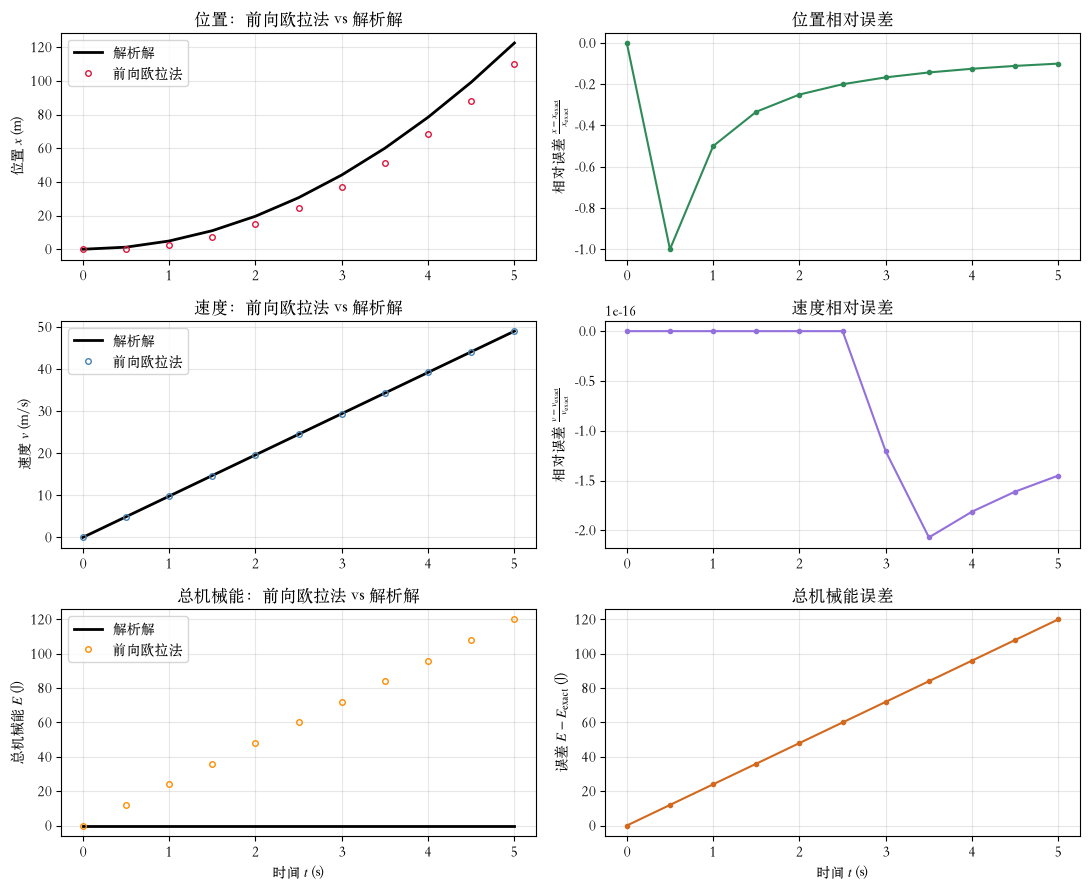

In [3]:
# 参数
x0, v0 = 0.0, 0.0   # 初始位置 (m)、初速度 (m/s)
m = 1.0             # 质量 (kg)
g = 9.8             # 重力加速度 (m/s^2)
h = 0.5             # 时间步长 (s)
t_end = 5.0         # 总时间 (s)

t, x, v = forward_euler_free_fall(x0, v0, g, h, int(t_end / h))
x_exact = x0 + v0 * t + 0.5 * g * t**2
v_exact = v0 + g * t

# 总机械能：E = 1/2 m v^2 - m g x（x 轴向下，取 x=0 处势能为零）
E = 0.5 * m * v**2 - m * g * x
E_exact = 0.5 * m * v_exact**2 - m * g * x_exact

# 位置相对误差（t=0 时 x_exact=0，该点误差恰为 0，直接取 0）
rel_err_x = np.zeros_like(x)
mask = x_exact != 0
rel_err_x[mask] = (x[mask] - x_exact[mask]) / x_exact[mask]

# 速度相对误差（t=0 时 v_exact=0，同上取 0）
rel_err_v = np.zeros_like(v)
mask_v = v_exact != 0
rel_err_v[mask_v] = (v[mask_v] - v_exact[mask_v]) / v_exact[mask_v]

# 总能量误差（带符号）：解析总能量恒为 0，相对误差无定义
E_err = E - E_exact[0]

print(f'位置最大相对误差 = {np.abs(rel_err_x).max():.3e}')
print(f'速度最大相对误差 = {np.abs(rel_err_v).max():.3e}')
print(f'解析总能量 = {E_exact[0]:.3e} J（守恒）')
print(f'数值总能量漂移 = {E[-1] - E_exact[0]:.3e} J')
print(f'末速度 = {v[-1]:.2f} m/s，末位置 = {x[-1]:.2f} m（解析值 {x_exact[-1]:.2f} m）')

fig, axs = plt.subplots(3, 2, figsize=(11, 9))

# 左列：数值解 vs 解析解
ax = axs[0, 0]
ax.plot(t, x_exact, 'k-', lw=2, label='解析解')
ax.plot(t, x, 'o', ms=4, mfc='none', color='crimson', label='前向欧拉法')
ax.set_ylabel('位置 $x$ (m)')
ax.set_title('位置：前向欧拉法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[1, 0]
ax.plot(t, v_exact, 'k-', lw=2, label='解析解')
ax.plot(t, v, 'o', ms=4, mfc='none', color='steelblue', label='前向欧拉法')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_title('速度：前向欧拉法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[2, 0]
ax.plot(t, np.full_like(t, E_exact[0]), 'k-', lw=2, label='解析解')
ax.plot(t, E, 'o', ms=4, mfc='none', color='darkorange', label='前向欧拉法')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总机械能 $E$ (J)')
ax.set_title('总机械能：前向欧拉法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

# 右列：对应的误差
ax = axs[0, 1]
ax.plot(t, rel_err_x, '.-', color='seagreen')
ax.set_ylabel('相对误差 $\\frac{x - x_{\\mathrm{exact}}}{x_{\\mathrm{exact}}}$')
ax.set_title('位置相对误差')
ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.plot(t, rel_err_v, '.-', color='mediumpurple')
ax.set_ylabel('相对误差 $\\frac{v - v_{\\mathrm{exact}}}{v_{\\mathrm{exact}}}$')
ax.set_title('速度相对误差')
ax.grid(alpha=0.3)

ax = axs[2, 1]
ax.plot(t, E_err, '.-', color='chocolate')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('误差 $E - E_{\\mathrm{exact}}$ (J)')
ax.set_title('总机械能误差')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/2_free_fall_euler_main.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 收敛性分析：减小步长 $h$ 的效果

下面用一系列从粗到细的步长重复计算：表格给出末位置误差与"减半比"，右图用对数坐标展示末位置误差、能量漂移随 $h$ 的变化。

**先预测，再运行**：步长每减半，末位置误差与能量漂移各变为几分之一？对数坐标中误差–$h$ 曲线的斜率是多少？

   h (s)        末位置误差 (m)        减半比       能量漂移 (J)
   0.500       1.2250e+01         --     1.2005e+02
   0.250       6.1250e+00       2.00     6.0025e+01
   0.100       2.4500e+00       2.50     2.4010e+01
   0.050       1.2250e+00       2.00     1.2005e+01
   0.025       6.1250e-01       2.00     6.0025e+00
   0.010       2.4500e-01       2.50     2.4010e+00


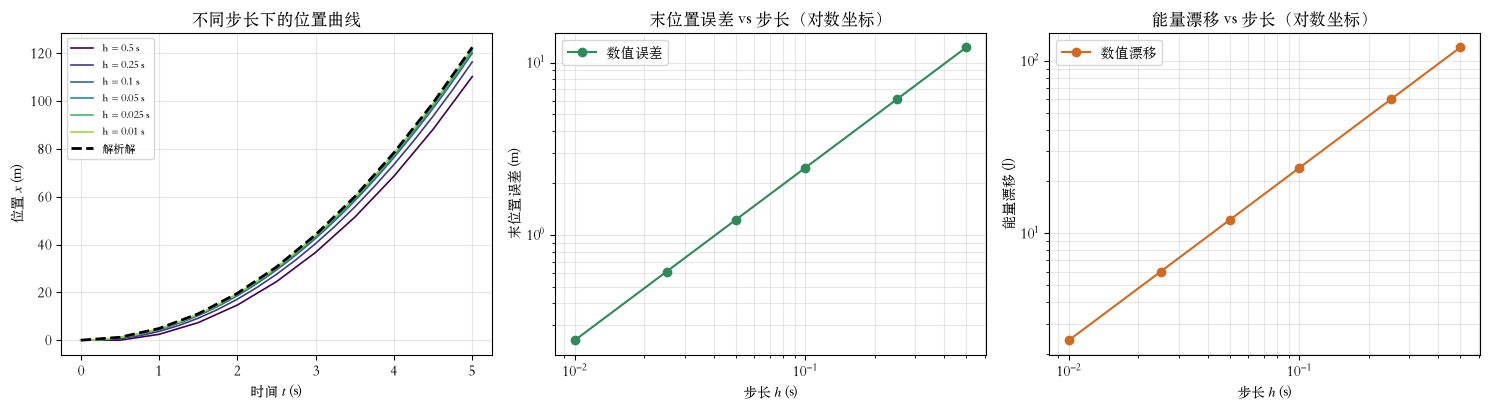

In [4]:
# 一系列从粗到细的步长
h_list = [0.5, 0.25, 0.1, 0.05, 0.025, 0.01]

fig, (axs0, axs1, axs2) = plt.subplots(1, 3, figsize=(15, 4.2))

x_err_end = []    # 末位置绝对误差
E_drift_end = []  # 末时刻能量漂移

print(f'{"h (s)":>8} {"末位置误差 (m)":>16} {"减半比":>10} {"能量漂移 (J)":>14}')
for h_i, c in zip(h_list, plt.cm.viridis(np.linspace(0, 0.85, len(h_list)))):
    t_i, x_i, v_i = forward_euler_free_fall(x0, v0, g, h_i, int(t_end / h_i))
    x_ex_i = x0 + v0 * t_i + 0.5 * g * t_i**2
    E_i = 0.5 * m * v_i**2 - m * g * x_i

    err_i = abs(x_i[-1] - x_exact[-1])
    drift_i = abs(E_i[-1] - E_exact[0])
    x_err_end.append(err_i)
    E_drift_end.append(drift_i)

    ratio = f'{x_err_end[-2] / err_i:.2f}' if len(x_err_end) > 1 else '--'
    print(f'{h_i:>8.3f} {err_i:>16.4e} {ratio:>10} {drift_i:>14.4e}')

    axs0.plot(t_i, x_i, '-', lw=1.2, color=c, label=f'h = {h_i} s')

# 不同步长下的位置曲线：随 h 减小逐渐贴合解析解
axs0.plot(t, x_exact, 'k--', lw=2, label='解析解')
axs0.set_xlabel('时间 $t$ (s)')
axs0.set_ylabel('位置 $x$ (m)')
axs0.set_title('不同步长下的位置曲线')
axs0.legend(fontsize=8)
axs0.grid(alpha=0.3)

# 末位置误差 vs h（对数坐标）
h_arr = np.array(h_list)
axs1.loglog(h_list, x_err_end, 'o-', color='seagreen', label='数值误差')
axs1.set_xlabel('步长 $h$ (s)')
axs1.set_ylabel('末位置误差 (m)')
axs1.set_title('末位置误差 vs 步长（对数坐标）')
axs1.legend()
axs1.grid(alpha=0.3, which='both')

# 能量漂移 vs h（对数坐标）
axs2.loglog(h_list, E_drift_end, 'o-', color='chocolate', label='数值漂移')
axs2.set_xlabel('步长 $h$ (s)')
axs2.set_ylabel('能量漂移 (J)')
axs2.set_title('能量漂移 vs 步长（对数坐标）')
axs2.legend()
axs2.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig('outputs/2_free_fall_euler_convergence.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**读图**：从表格中的"减半比"与对数图的斜率，你能总结出末位置误差、能量漂移对步长 $h$ 的依赖关系吗？与运行前的预测一致吗？

## 速度相空间矢量场

自由落体在速度相空间 $(x, v)$ 中的矢量场为

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = g
$$

箭头始终带有向下的分量 $g$，水平分量随 $v$ 变化。

几个要点：

- **无平衡点**：$\dot v = g$ 处处不为零，速度相空间中不存在静止状态——与单摆（中心 + 鞍点）、简谐振子（中心）的结构完全不同。
- **轨道为抛物线**：等能线 $E = \tfrac{1}{2}mv^2 - mgx = $ const 是一族向右开口的抛物线 $x = \tfrac{v^2}{2g} - \tfrac{E}{mg}$：$v > 0$ 段对应下落加速（$x$、$v$ 同增），$v < 0$ 段对应上抛减速。
- **能量漂移的几何图像**：真实轨道恰好沿一条等能线运动。思考：数值解的轨道会相对这族等能线向哪一侧穿越？方向由什么决定？（提示：能量每步是否守恒？可结合结论部分的能量收支解释。）

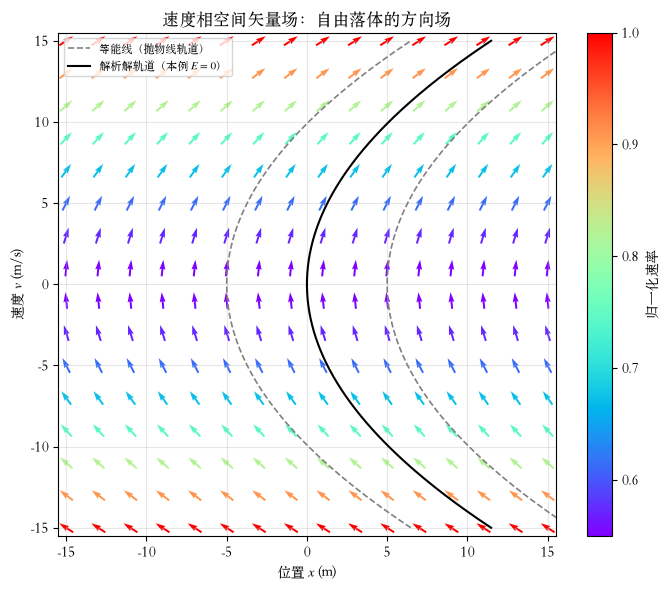

In [5]:
# 速度相空间矢量场：(dx/dt, dv/dt) = (v, g)
# 箭头归一化为单位长度（只表示方向），颜色表示归一化速率
# 全空间无平衡点（dv/dt = g 恒不为零），轨道为向右开口的抛物线
x_grid = np.linspace(-15.0, 15.0, 16)
v_grid = np.linspace(-15.0, 15.0, 16)
X, V = np.meshgrid(x_grid, v_grid)

U, W = V, np.full_like(X, g)
speed = np.sqrt(U**2 + W**2)
speed_norm = speed / speed.max()

fig, ax = plt.subplots(figsize=(7, 6))
q = ax.quiver(X, V, U / speed, W / speed, speed_norm, cmap='rainbow',
              pivot='mid', scale=30, width=0.004)
cbar = fig.colorbar(q, ax=ax)
cbar.set_label('归一化速率')

# 等能线：E = 1/2 m v^2 - m g x = const，向右开口的抛物线
v_line = np.linspace(-15.0, 15.0, 301)
for dx0 in (-5.0, 5.0):
    ax.plot(v_line**2 / (2 * g) + dx0, v_line, '--', color='gray', lw=1.2,
            label='等能线（抛物线轨道）' if dx0 == 5.0 else None)

# 本算例的解析解轨道：E = 0，即 x = v^2/(2g)
ax.plot(v_line**2 / (2 * g), v_line, 'k-', lw=1.5,
        label='解析解轨道（本例 $E = 0$）')

ax.set_xlabel('位置 $x$ (m)')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_xlim(-15.5, 15.5)
ax.set_ylim(-15.5, 15.5)
ax.set_title('速度相空间矢量场：自由落体的方向场')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('outputs/2_free_fall_euler_field.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

### 箭头的位置与颜色约定

- **位置**：每个箭头按 `pivot='mid'` 绘制——箭杆的**中点**恰落在它所描述的速度相空间格点 $(x_i,\,v_i)$ 上，并沿该点处的流方向对称延伸。读图时以箭杆中点为准。
- **颜色**：箭杆归一化为单位长度（只表示方向），矢量的**模长**改用颜色编码：按 $|(\dot x, \dot v)|\,/\,|(\dot x, \dot v)|_{\max}$ 以 rainbow 色条从蓝（慢）到红（快）着色。本例 $(\dot x, \dot v) = (v,\,g)$，模长 $=\sqrt{v^2+g^2}$，故 $|v|$ 越大颜色越红，$v=0$ 附近最慢（蓝）。

方向（箭头指向）+ 模长（颜色）合在一起，完整给出矢量场的信息。

## 结论与思考

**先对照运行结果，回答引言中的四个预测**（速度是否精确？位置超前还是滞后？能量是否守恒、如何增长？步长减半会怎样？）

**一个值得注意的对比**：位置误差是"良性的"——相对误差随 $t$ 衰减、可通过减小步长控制；而能量漂移随 $t$ **无界累积**（这里漂移 $\propto h\,t$）：只要时间够长，无论步长多小，数值能量终将显著偏离真实值。这是更新格式本身的**结构性缺陷**，不是"精度不够"的问题——减小步长只能延缓，不能根除。